# Fuel Cost-Shock Forecaster — Multi-Agent + Statistical Baseline

Adapted from the [`energy_oil_forecasting`](../energy_oil_forecasting/) (WTI) reference implementation.

**Architecture: 2 agents + 1 statistical model**

| Component | Section | Role |
|---|---|---|
| Commodity-Data Agent | §1 | `DataService`: yfinance (HO=F, CL=F, DX-Y.NYB) + FRED + EIA |
| Geopolitical/News Agent | §2 | `ContextRetrievalConfig` sub-agent with temporal-leakage verifier |
| Logistic Regression | §5–6 | Expanding-window statistical baseline — same features as agent, no LLM |
| V1 Hybrid Agent | §3, §5, §7 | LR sets the anchor; agent adjusts only on confirmed supply events |

**Evaluation pipeline:**
1. **§5 LR Signal Scan** — LR across all horizon × threshold combinations to find where signal lives
2. **§5 (post-scan)** — register dynamic shock series at best horizon/threshold; build task spec and predictor
3. **§6 Rigorous LR Backtest** — CV-selected hyperparameters, dynamic class weights, no hardcoding
4. **§7 V1 Hybrid Backtest** — same spec as §6; key question: does news adjustment beat LR alone?
5. **§8 Final Leaderboard** — all predictors on identical origins

**Leakage controls (all fixed):**
- Expanding training window strictly before origin at every LR call
- `C` selected by `TimeSeriesSplit` CV within training window — scaler re-instantiated per C candidate
- `class_weight` computed via sklearn balanced formula `N/(2·n_c)` from training labels
- Task spec horizon and threshold built after signal scan — no hardcoded prediction target
- Dynamic shock series (`fuel_cost_shock_event_best`) registered after scan so LR training labels,
  agent labels, and backtest scoring target all use the same horizon/threshold
- Fallback = empirical training mean, not a hardcoded constant


In [1]:
import json
import math
import os
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yaml
from IPython.display import Markdown, display  # noqa: A004
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters.base import BaseAdapter
from aieng.forecasting.data.adapters.fred import FREDAdapter
from aieng.forecasting.data.adapters.yfinance import YFinanceDailyAdapter
from aieng.forecasting.data.context import ForecastContext
from aieng.forecasting.evaluation import BacktestSpec, cached_backtest
from aieng.forecasting.evaluation.backtest import BacktestResult, compute_brier_score
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods import HistoricalFrequencyPredictor
from aieng.forecasting.methods.agentic import (
    AgentPredictor,
    ContinuousAgentForecastOutput,
    DiscreteAgentForecastOutput,
)
from aieng.forecasting.methods.agentic.agent_factory import AgentConfig, ContextRetrievalConfig
from aieng.forecasting.models import ADVANCED_MODEL, LITE_MODEL
from dotenv import load_dotenv
from pydantic import BaseModel


warnings.filterwarnings("ignore")
load_dotenv()

AGENT_MODEL    = LITE_MODEL
SEARCH_MODEL   = LITE_MODEL
VERIFIER_MODEL = ADVANCED_MODEL

# ── Default series parameters (used only for the always-registered 21d/10% DataService series)
_DEFAULT_SHOCK_THRESHOLD_PCT = 0.10
_DEFAULT_SHOCK_HORIZON_DAYS  = 21
TRAJECTORY_HORIZONS          = [5, 10, 21]

# ── Dynamic best-target placeholders — set by §5 signal scan ─────────────────
BEST_HORIZON               = None   # set after signal scan
BEST_THRESHOLD             = None   # set after signal scan
BEST_SHOCK_EVENT_SERIES_ID = "fuel_cost_shock_event_best"  # registered after scan


def naive_utc_now() -> datetime:
    return datetime.now(tz=timezone.utc).replace(tzinfo=None)


def repo_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    root = cwd
    while not (root / "pyproject.toml").exists():
        if root.parent == root:
            return cwd / "data"
        root = root.parent
    data_dir = root / "data"
    data_dir.mkdir(exist_ok=True)
    return data_dir


DATA_DIR = repo_data_dir()
print(f"Data cache root: {DATA_DIR}")
print("All imports loaded. BEST_HORIZON and BEST_THRESHOLD will be set after §5 signal scan.")


Data cache root: /home/coder/agentic-forecasting/implementations/data
All imports loaded. BEST_HORIZON and BEST_THRESHOLD will be set after §5 signal scan.


---
## 1. Commodity-Data Agent

Realised as a `DataService` registration layer, not a separate LLM call — every reference implementation in this repo (WTI, BoC, S&P 500) treats quantitative time-series data as a structured prompt payload, not something an agent fetches or summarizes. `FuelMultitaskPromptBuilder` (§4) builds the payload from the service below, fulfilling this agent's role structurally.

**Data sources (doc §6):**

| Source | Series | Key required? |
|---|---|---|
| yfinance | jet-fuel proxy `HO=F`, WTI `CL=F`, USD index `DX-Y.NYB` | No |
| FRED | `DEXCAUS` (CAD/USD spot FX) — stands in for the doc's "Bank of Canada Valet API" (no Valet adapter exists in this repo; FRED covers the same signal) | `FRED_API_KEY` (set) |
| EIA Open Data | `RWTC` (WTI Cushing spot), `EER_EPJK_PF4_RGC_DPG` (US Gulf Coast jet-fuel spot) — verified against `eia-api-swagger.yaml` | `EIA_API_KEY` (set) |

EIA inventory/stocks series (`petroleum/stoc/...`) are **not yet added** — not verified against the swagger file yet. GDELT 2.0 (doc's alternative news feed) is not evaluated.

In [2]:
# ── EIA Open Data adapter (API v2) ────────────────────────────────────────────────
# Not a pre-existing aieng adapter -- built here against eia-api-swagger.yaml
# (route: /v2/petroleum/{route1}/{route2}/data, params: api_key, frequency,
# data[], facets[series][], sort[0][column]/[direction], offset, length).
# Mirrors FREDAdapter's cache-to-parquet convention.

EIA_BASE_URL = "https://api.eia.gov/v2"
EIA_PAGE_LENGTH = 5000  # API max rows per request


class EIAAdapter(BaseAdapter):
    """Adapter for a single EIA Open Data API v2 petroleum series, with disk cache.

    Parameters
    ----------
    route1, route2 : str
        EIA route segments, e.g. ``"pri", "spt"`` for spot prices.
    series_id : str
        EIA facet series id, e.g. ``"RWTC"`` or ``"EER_EPJK_PF4_RGC_DPG"``.
    frequency : str
        EIA frequency string (``"daily"``, ``"weekly"``, ...).
    api_key : str or None
        EIA API key. Defaults to the ``EIA_API_KEY`` environment variable.
    cache_dir : Path or None
        Parquet cache directory. Defaults to ``data/eia``.
    refresh : bool
        Force a network re-fetch even if a cache file exists.
    """

    def __init__(
        self,
        route1: str,
        route2: str,
        series_id: str,
        *,
        frequency: str = "daily",
        api_key: str | None = None,
        cache_dir: Path | None = None,
        refresh: bool = False,
    ) -> None:
        self._route1 = route1
        self._route2 = route2
        self._series_id = series_id
        self._frequency = frequency
        self._api_key = api_key or os.environ.get("EIA_API_KEY")
        self._cache_dir = cache_dir if cache_dir is not None else DATA_DIR / "eia"
        self._refresh = refresh

    @property
    def cache_path(self) -> Path:
        return self._cache_dir / f"{self._series_id}.parquet"

    def fetch(self) -> pd.DataFrame:
        if self.cache_path.exists() and not self._refresh:
            df = pd.read_parquet(self.cache_path)
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["released_at"] = pd.to_datetime(df["released_at"])
            return df

        df = self._fetch_from_api()
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(self.cache_path, index=False)
        return df

    def _fetch_from_api(self) -> pd.DataFrame:
        if not self._api_key:
            raise ValueError(
                "EIA API key not provided. Set the EIA_API_KEY environment variable "
                "or pass api_key= to EIAAdapter."
            )

        url = f"{EIA_BASE_URL}/petroleum/{self._route1}/{self._route2}/data/"
        rows: list[dict] = []
        offset = 0
        while True:
            params = {
                "api_key": self._api_key,
                "frequency": self._frequency,
                "data[0]": "value",
                "facets[series][]": self._series_id,
                "sort[0][column]": "period",
                "sort[0][direction]": "asc",
                "offset": offset,
                "length": EIA_PAGE_LENGTH,
            }
            resp = requests.get(url, params=params, timeout=30)
            resp.raise_for_status()
            payload = resp.json()["response"]
            page = payload["data"]
            rows.extend(page)
            if len(page) < EIA_PAGE_LENGTH:
                break
            offset += EIA_PAGE_LENGTH

        if not rows:
            raise RuntimeError(f"EIA series '{self._series_id}' returned no data.")

        df = pd.DataFrame(rows)
        df["timestamp"] = pd.to_datetime(df["period"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["value"]).sort_values("timestamp").reset_index(drop=True)
        df["released_at"] = df["timestamp"]  # EIA doesn't expose vintage dates via this route
        return df[["timestamp", "value", "released_at"]]

    def __repr__(self) -> str:
        return f"EIAAdapter(route={self._route1}/{self._route2}, series_id={self._series_id!r})"


print("EIAAdapter defined.")

EIAAdapter defined.


In [3]:
# ── Canonical series IDs ──────────────────────────────────────────────────────
FUEL_SERIES_ID              = "jet_fuel_proxy_price"
WTI_SERIES_ID               = "wti_crude_oil_price"
USD_INDEX_SERIES_ID         = "usd_index_price"
CAD_USD_FX_SERIES_ID        = "cad_usd_fx_rate"
EIA_WTI_SPOT_SERIES_ID      = "eia_wti_spot_price"
EIA_JET_FUEL_SPOT_SERIES_ID = "eia_jet_fuel_spot_price"
# The always-registered default series (21d/10%) — used only for live pipeline
SHOCK_EVENT_SERIES_ID_DEFAULT = "fuel_cost_shock_event_21d"

_FUEL_TICKER       = "HO=F"
_WTI_TICKER        = "CL=F"
_USD_INDEX_TICKER  = "DX-Y.NYB"
_HISTORY_START     = "2004-01-01"


def derive_shock_event_series(
    price_df: pd.DataFrame,
    *,
    horizon_days: int,
    threshold_pct: float,
) -> pd.DataFrame:
    """Derive rolling binary shock series. timestamp=t, value=1{price[t+h]/price[t]-1>thr},
    released_at=t+h so CutoffEnforcer hides it until resolved."""
    df = price_df.sort_values("timestamp").reset_index(drop=True)
    ts  = pd.to_datetime(df["timestamp"])
    val = df["value"].astype(float)
    n   = len(df)
    if n <= horizon_days:
        return pd.DataFrame(columns=["timestamp", "value", "released_at"])
    origin   = val.iloc[: n - horizon_days].reset_index(drop=True)
    resolved = val.iloc[horizon_days:].reset_index(drop=True)
    return pd.DataFrame({
        "timestamp":   ts.iloc[: n - horizon_days].reset_index(drop=True),
        "value":       (resolved / origin - 1.0 > threshold_pct).astype(float),
        "released_at": ts.iloc[horizon_days:].reset_index(drop=True),
    })


class FuelShockEventAdapter(BaseAdapter):
    def __init__(self, price_adapter, *, horizon_days: int, threshold_pct: float) -> None:
        self._price_adapter = price_adapter
        self._horizon_days  = horizon_days
        self._threshold_pct = threshold_pct

    def fetch(self) -> pd.DataFrame:
        return derive_shock_event_series(
            self._price_adapter.fetch(),
            horizon_days=self._horizon_days,
            threshold_pct=self._threshold_pct,
        )


def build_fuel_service(cache_dir: Path | None = None) -> DataService:
    """Build DataService. Registers the default 21d/10% shock series for the live pipeline.
    The best-horizon shock series (BEST_SHOCK_EVENT_SERIES_ID) is registered
    separately after the signal scan via register_best_shock_series().
    """
    resolved_cache_dir = cache_dir if cache_dir is not None else DATA_DIR / "yfinance"
    svc = DataService()

    fuel_adapter = YFinanceDailyAdapter(
        ticker=_FUEL_TICKER, start=_HISTORY_START, cache_dir=resolved_cache_dir
    )
    svc.register(FUEL_SERIES_ID, fuel_adapter,
        SeriesMetadata(series_id=FUEL_SERIES_ID,
            description="NY Harbor ULSD / Heating Oil front-month futures (HO=F) — jet-fuel proxy.",
            source="yfinance", units="USD/gal", frequency="B"))

    # Default shock series: 21d / 10% — used only for live pipeline display
    svc.register(SHOCK_EVENT_SERIES_ID_DEFAULT,
        FuelShockEventAdapter(fuel_adapter,
            horizon_days=_DEFAULT_SHOCK_HORIZON_DAYS,
            threshold_pct=_DEFAULT_SHOCK_THRESHOLD_PCT),
        SeriesMetadata(series_id=SHOCK_EVENT_SERIES_ID_DEFAULT,
            description=(
                f"Cost-shock: 1.0 if HO=F rises >{_DEFAULT_SHOCK_THRESHOLD_PCT:.0%} "
                f"over {_DEFAULT_SHOCK_HORIZON_DAYS} business days."
            ),
            source="Derived (HO=F)", units="0/1", frequency="B"))

    svc.register(WTI_SERIES_ID,
        YFinanceDailyAdapter(ticker=_WTI_TICKER, start=_HISTORY_START, cache_dir=resolved_cache_dir),
        SeriesMetadata(series_id=WTI_SERIES_ID,
            description="WTI Crude Oil front-month futures (CL=F)",
            source="yfinance", units="USD/bbl", frequency="B"))

    svc.register(USD_INDEX_SERIES_ID,
        YFinanceDailyAdapter(ticker=_USD_INDEX_TICKER, field="Adj Close",
                             start=_HISTORY_START, cache_dir=resolved_cache_dir),
        SeriesMetadata(series_id=USD_INDEX_SERIES_ID,
            description="US Dollar Index (DX-Y.NYB)",
            source="yfinance", units="index-level", frequency="B"))

    try:
        svc.register(CAD_USD_FX_SERIES_ID,
            FREDAdapter("DEXCAUS", cache_dir=DATA_DIR / "fred"),
            SeriesMetadata(series_id=CAD_USD_FX_SERIES_ID,
                description="CAD/USD spot FX (FRED DEXCAUS)",
                source="FRED", units="CAD per USD", frequency="B"))
    except (RuntimeError, ValueError) as exc:
        warnings.warn(f"Skipping CAD/USD FX: {exc}", stacklevel=2)

    try:
        svc.register(EIA_WTI_SPOT_SERIES_ID,
            EIAAdapter("pri", "spt", "RWTC"),
            SeriesMetadata(series_id=EIA_WTI_SPOT_SERIES_ID,
                description="Cushing WTI spot (EIA RWTC)",
                source="EIA", units="USD/bbl", frequency="B"))
        svc.register(EIA_JET_FUEL_SPOT_SERIES_ID,
            EIAAdapter("pri", "spt", "EER_EPJK_PF4_RGC_DPG"),
            SeriesMetadata(series_id=EIA_JET_FUEL_SPOT_SERIES_ID,
                description="US Gulf Coast jet-fuel spot (EIA EER_EPJK_PF4_RGC_DPG)",
                source="EIA", units="USD/gal", frequency="B"))
    except (RuntimeError, ValueError) as exc:
        warnings.warn(f"Skipping EIA spot covariates: {exc}", stacklevel=2)

    return svc


def register_best_shock_series(
    svc: DataService,
    horizon_days: int,
    threshold_pct: float,
) -> None:
    """Register the best-horizon shock series after signal scan.

    This is the series used by LR training labels, HybridFuelPromptBuilder,
    and the §6/§7 backtest scoring target — ensuring all three use the
    exact same horizon and threshold, eliminating the mismatch bug.
    """
    full_ctx  = svc.context(as_of=naive_utc_now())
    fuel_df   = full_ctx.get_series(FUEL_SERIES_ID)
    fuel_adapter = YFinanceDailyAdapter(
        ticker=_FUEL_TICKER, start=_HISTORY_START,
        cache_dir=DATA_DIR / "yfinance"
    )
    best_adapter = FuelShockEventAdapter(
        fuel_adapter, horizon_days=horizon_days, threshold_pct=threshold_pct
    )
    # Re-register if already exists (signal scan may be rerun)
    try:
        svc.register(
            BEST_SHOCK_EVENT_SERIES_ID,
            best_adapter,
            SeriesMetadata(
                series_id=BEST_SHOCK_EVENT_SERIES_ID,
                description=(
                    f"Best-signal shock: 1.0 if HO=F rises >{threshold_pct:.0%} "
                    f"over {horizon_days} business days."
                ),
                source="Derived (HO=F)", units="0/1", frequency="B",
            ),
        )
    except Exception:
        # Already registered — update the adapter by deregistering and re-registering
        svc._adapters[BEST_SHOCK_EVENT_SERIES_ID]  = best_adapter
        svc._metadata[BEST_SHOCK_EVENT_SERIES_ID]  = SeriesMetadata(
            series_id=BEST_SHOCK_EVENT_SERIES_ID,
            description=(
                f"Best-signal shock: 1.0 if HO=F rises >{threshold_pct:.0%} "
                f"over {horizon_days} business days."
            ),
            source="Derived (HO=F)", units="0/1", frequency="B",
        )
    print(f"Registered '{BEST_SHOCK_EVENT_SERIES_ID}' "
          f"(horizon={horizon_days}d, threshold={threshold_pct:.0%})")


print("build_fuel_service() and register_best_shock_series() defined.")


build_fuel_service() and register_best_shock_series() defined.


In [4]:
data_service = build_fuel_service()
ctx0 = data_service.context(as_of=naive_utc_now())
fuel_df = ctx0.get_series(FUEL_SERIES_ID)
print(f"HO=F history through {pd.Timestamp(fuel_df['timestamp'].max()).date()}, {len(fuel_df)} rows")
print(f"Registered series: {list(data_service.series_ids)}")


HO=F history through 2026-10-02, 5721 rows
Registered series: ['cad_usd_fx_rate', 'eia_jet_fuel_spot_price', 'eia_wti_spot_price', 'fuel_cost_shock_event_21d', 'jet_fuel_proxy_price', 'usd_index_price', 'wti_crude_oil_price']


---
## 2. Geopolitical / News Agent

A `ContextRetrievalConfig` sub-agent (the same primitive `energy_oil_forecasting` uses for its news-grounded configs) with a temporal-leakage verifier, wired into the Forecaster Agent below as the `search_web` tool. GDELT 2.0 (doc's alternative feed) is not wired up here.

In [5]:
FUEL_NEWS_INSTRUCTION = """
You are a jet-fuel and crude-oil market intelligence specialist with access to web search.

Search for information relevant to the query and return a concise structured markdown summary (3-5 paragraphs) covering relevant aspects of:
- Crude oil (WTI/Brent) and refined-products (jet fuel / heating oil / diesel) price level and recent trend
- OPEC+ production decisions and supply outlook
- Geopolitical risks in the Persian Gulf, Middle East, Strait of Hormuz, and other key shipping lanes affecting crude and product tanker flows
- US EIA policy releases, Strategic Petroleum Reserve actions, and inventory data surprises
- Refinery outages or disruptions affecting jet fuel / distillate supply
- Notable analyst forecasts or unusual price-target revisions for crude or refined products

Ground your summary in the search results you actually retrieve. When a cutoff date is specified, do not report or speculate about events that occurred after that date.

Before finalizing your summary, reason step by step: (1) for each candidate fact, judge its actual recency from the substance of the result itself, never from a source's claimed publish date or byline timestamp -- those are frequently stale or updated after original publication; (2) discard anything you cannot confidently place before the cutoff date; (3) only then write your summary. Do not supplement the search results with your own background/training knowledge -- if the results are insufficient, say so explicitly rather than filling gaps from memory.
""".strip()

FUEL_CONTEXT_RETRIEVAL_SUPPLEMENT = """

## Context retrieval

Call ``search_web`` to gather market intelligence BEFORE producing forecasts.

Call ``search_web`` with ``query`` and ``cutoff_date`` (set to the ``as_of`` date from the payload). The ``cutoff_date`` MUST always equal ``as_of`` -- this is the temporal fence that prevents post-origin information from contaminating historical backtests.

If ``search_web`` returns a result beginning with ``[SEARCH_VERIFICATION_FAILED]``, treat it as no verified news context for that query. Do not use your own background knowledge to fill the gap or speculate about what the news might have said -- proceed with price-history and other available signals only, and note the gap in your rationale.

Recommended queries (call ``search_web`` once per topic):
- ``search_web(query="crude oil and jet fuel price trend and OPEC+ supply decisions", cutoff_date=<as_of>)``
- ``search_web(query="Persian Gulf geopolitical risk shipping lane disruptions", cutoff_date=<as_of>)``
- ``search_web(query="US EIA policy releases and Strategic Petroleum Reserve actions", cutoff_date=<as_of>)``
- ``search_web(query="refinery outages affecting jet fuel and distillate supply", cutoff_date=<as_of>)``
"""


def build_fuel_context_retrieval_config(
    search_model: str = SEARCH_MODEL,
    verifier_model: str = VERIFIER_MODEL,
    verifier_max_attempts: int = 3,
    verifier_confidence_threshold: int = 8,
) -> ContextRetrievalConfig:
    """Build the Geopolitical/News Agent's :class:`ContextRetrievalConfig`."""
    return ContextRetrievalConfig(
        enabled=True,
        instruction=FUEL_NEWS_INSTRUCTION,
        search_model=search_model,
        verifier_model=verifier_model,
        verifier_max_attempts=verifier_max_attempts,
        verifier_confidence_threshold=verifier_confidence_threshold,
    )


print("News Agent instruction + factory defined.")

News Agent instruction + factory defined.


---
## 3. Forecaster Agent — Core Components

Defines the forecaster config, feature builder, **fixed** `_lr_predict_at_origin` helper,
`HybridFuelPromptBuilder`, and `TaggedPredictor`.

**The task spec and predictor are built in §5 after the signal scan** so that
`BEST_HORIZON`, `BEST_THRESHOLD`, and `BEST_SHOCK_EVENT_SERIES_ID` are known.

**Fixes applied to `_lr_predict_at_origin`:**
- Class weight uses sklearn balanced formula: `w_c = N / (2 · n_c)` — minority class
  (shocks) gets higher weight, majority class (no-shock) gets lower weight
- `StandardScaler` re-instantiated inside each C candidate's loop — no state bleed
  between candidates
- Dead first `y_train` assignment removed
- `HybridFuelPromptBuilder` uses `BEST_SHOCK_EVENT_SERIES_ID` for label fetching
  (set after signal scan) — same series used for training, prompting, and scoring


In [6]:
# sklearn imported in cell 01

FUEL_FORECASTER_INSTRUCTION = """
## Role

You are an expert jet-fuel and crude-oil market analyst. A logistic regression model has already
computed a base probability from quantitative price signals. Your role is narrow and specific:
assess whether confirmed qualitative information justifies deviating from that statistical estimate.

## Input fields

- `task_spec`: the question, deviation rules, and required JSON output schema
- `as_of`: your temporal cutoff — never use information after this date
- `lr_probability`: the logistic regression model's probability estimate at this origin
- `lr_features`: the feature values used by the LR model (for context)
- `origin_price_usd_gal`: HO=F closing price on the origin date
- `momentum_signals`: HO=F 5d/21d returns and 21d rolling volatility
- `covariate_summary`: WTI crude and USD index 21d returns
- `target_history_csv`: compressed HO=F daily close history

## Deviation rules

Start from `lr_probability`. Only deviate if `search_web` returns **confirmed** evidence of:
- An active, confirmed supply disruption (refinery outage, pipeline closure, tanker incident)
- A confirmed OPEC+ production cut announced since the last price data point
- A confirmed force majeure event affecting crude or distillate supply

Do NOT deviate for: geopolitical tension, rumours, analyst forecasts, risk premiums, or anything
that is not a confirmed physical supply event. Markets price tension immediately — it is already
in the price history the LR model used.

## Output contract

Execute the task in `task_spec` precisely. In `reasoning`, explain:
(1) what lr_probability was, (2) what news you found, (3) whether you deviated and why.
If a `set_model_response` tool is available, call it with your complete JSON as `json_response`.
Otherwise return the JSON directly as plain text with no preamble.
""".strip()


def build_fuel_forecaster_config(
    model: str = AGENT_MODEL,
    search_model: str = SEARCH_MODEL,
    verifier_model: str = VERIFIER_MODEL,
) -> AgentConfig:
    return AgentConfig(
        name="fuel_shock_forecaster",
        model=model,
        instruction=FUEL_FORECASTER_INSTRUCTION,
        context_retrieval=build_fuel_context_retrieval_config(
            search_model=search_model, verifier_model=verifier_model
        ),
    )


def _compress_history(df: pd.DataFrame) -> str:
    frame  = df.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    cutoff = frame["timestamp"].max() - pd.DateOffset(months=6)
    recent = frame[frame["timestamp"] >= cutoff]
    old    = frame[frame["timestamp"] < cutoff]
    rows: list[str] = ["date,close"]
    if not old.empty:
        weekly = old.set_index("timestamp")["value"].resample("W").mean().dropna()
        rows.extend(f"{d.date()},{v:.3f}" for d, v in weekly.items())
    rows.extend(f"{r['timestamp'].date()},{r['value']:.3f}" for _, r in recent.iterrows())
    return "\n".join(rows)


# ── Feature builder ────────────────────────────────────────────────────────────
FEATURE_COLS = ["ret_5d", "ret_21d", "vol_21d", "wti_ret_21d", "usd_ret_21d"]


def _build_features(
    fuel_df: pd.DataFrame,
    wti_df:  pd.DataFrame | None = None,
    usd_df:  pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Build daily feature DataFrame on HO=F trading dates."""
    fuel = fuel_df.set_index(pd.to_datetime(fuel_df["timestamp"]))["value"].astype(float)
    feats = pd.DataFrame(index=fuel.index)
    feats["ret_5d"]  = fuel.pct_change(5)
    feats["ret_21d"] = fuel.pct_change(21)
    feats["vol_21d"] = fuel.pct_change().rolling(21).std()
    if wti_df is not None:
        wti = wti_df.set_index(pd.to_datetime(wti_df["timestamp"]))["value"].astype(float)
        feats["wti_ret_21d"] = wti.reindex(feats.index, method="ffill").pct_change(21)
    else:
        feats["wti_ret_21d"] = 0.0
    if usd_df is not None:
        usd = usd_df.set_index(pd.to_datetime(usd_df["timestamp"]))["value"].astype(float)
        feats["usd_ret_21d"] = usd.reindex(feats.index, method="ffill").pct_change(21)
    else:
        feats["usd_ret_21d"] = 0.0
    return feats.fillna(0.0)


# ── LR helper (all bugs fixed) ────────────────────────────────────────────────
MIN_TRAIN_ROWS = 504  # 2 years of business days


def _lr_predict_at_origin(
    feats:     pd.DataFrame,
    labels:    pd.Series,
    origin_ts: pd.Timestamp,
    fallback:  float,
) -> tuple[float, dict]:
    """Fit expanding-window LR; predict at origin_ts. All bugs fixed:

    FIX 1 — class weight: sklearn balanced formula w_c = N / (2 * n_c).
             Minority class (shocks, class 1) gets HIGHER weight.
    FIX 2 — StandardScaler re-instantiated inside each C-candidate loop.
             No state bleed between candidates.
    FIX 3 — removed dead first y_train assignment that was immediately overwritten.
    """
    # Align labels and features on common dates before origin
    common_train = feats.index[feats.index < origin_ts].intersection(labels.index)
    X_train = feats.loc[common_train][FEATURE_COLS].values
    y_train = labels.loc[common_train].values

    # Feature vector at origin (last row <= origin_ts)
    origin_rows  = feats.loc[feats.index <= origin_ts]
    x_origin_raw = origin_rows.iloc[[-1]][FEATURE_COLS].values if not origin_rows.empty else None
    feat_dict    = dict(zip(FEATURE_COLS, x_origin_raw[0].tolist())) if x_origin_raw is not None else {}

    # Fallback if insufficient data
    if len(X_train) < MIN_TRAIN_ROWS or len(np.unique(y_train)) < 2 or x_origin_raw is None:
        return max(0.01, min(0.99, fallback)), feat_dict

    # FIX 1: sklearn balanced class weights — minority (shocks) gets higher weight
    n_total = len(y_train)
    n_pos   = int(y_train.sum())          # number of shocks (minority)
    n_neg   = n_total - n_pos             # number of no-shocks (majority)
    if n_pos == 0 or n_neg == 0:
        return max(0.01, min(0.99, fallback)), feat_dict
    # w_c = n_total / (2 * n_c) — same formula sklearn uses for class_weight='balanced'
    cw = {0: n_total / (2 * n_neg),   # lower weight for majority (no-shock)
          1: n_total / (2 * n_pos)}   # higher weight for minority (shock)

    # FIX 2: C selection via TimeSeriesSplit — scaler re-instantiated per C candidate
    C_candidates    = [0.01, 0.1, 1.0, 10.0]
    best_C, best_cv = 1.0, float("inf")
    tscv = TimeSeriesSplit(n_splits=min(5, len(X_train) // 50))
    if tscv.n_splits >= 2:
        for C in C_candidates:
            # FIX 2: fresh scaler per C candidate — no state bleed
            scaler_cv  = StandardScaler()
            fold_scores = []
            for tr_idx, val_idx in tscv.split(X_train):
                if len(np.unique(y_train[tr_idx])) < 2:
                    continue
                Xtr  = scaler_cv.fit_transform(X_train[tr_idx])
                Xval = scaler_cv.transform(X_train[val_idx])
                lr_cv = LogisticRegression(
                    C=C, max_iter=500, class_weight=cw, random_state=42
                )
                lr_cv.fit(Xtr, y_train[tr_idx])
                p_val = lr_cv.predict_proba(Xval)[:, 1]
                fold_scores.append(np.mean((p_val - y_train[val_idx]) ** 2))
            if fold_scores and np.mean(fold_scores) < best_cv:
                best_cv = np.mean(fold_scores)
                best_C  = C

    # Final fit on full training window with best_C
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    x_scaled = scaler.transform(x_origin_raw)
    lr = LogisticRegression(C=best_C, max_iter=1000, class_weight=cw, random_state=42)
    lr.fit(X_scaled, y_train)
    prob = float(lr.predict_proba(x_scaled)[0, 1])
    return max(0.01, min(0.99, prob)), feat_dict


# ── Trajectory prompt builder ─────────────────────────────────────────────────
class FuelMultitaskPromptBuilder(BaseModel):
    task_spec: str
    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context: ForecastContext) -> str:
        df       = context.get_series(task.target_series_id)
        last_row = df.iloc[-1]
        payload  = {
            "task": task.task_id, "task_spec": self.task_spec,
            "as_of": str(context.as_of)[:10], "horizons": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "origin_price_usd_gal": float(last_row["value"]),
            "target_history_csv": _compress_history(df),
        }
        return json.dumps(payload, indent=2)


# ── HybridFuelPromptBuilder ───────────────────────────────────────────────────
class HybridFuelPromptBuilder(BaseModel):
    """Runs LR at current origin and injects lr_probability into agent payload.

    Uses BEST_SHOCK_EVENT_SERIES_ID (set after signal scan) for label fetching
    so training labels and scoring target always use the same horizon/threshold.
    """
    task_spec: str
    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context: ForecastContext) -> str:
        fuel_df = context.get_series(FUEL_SERIES_ID)

        wti_df = None
        try:    wti_df = context.get_series(WTI_SERIES_ID)
        except Exception: pass

        usd_df = None
        try:    usd_df = context.get_series(USD_INDEX_SERIES_ID)
        except Exception: pass

        # FIX: use BEST_SHOCK_EVENT_SERIES_ID — same series used for scoring
        try:
            event_df = context.get_series(BEST_SHOCK_EVENT_SERIES_ID)
        except Exception:
            event_df = context.get_series(SHOCK_EVENT_SERIES_ID_DEFAULT)

        feats  = _build_features(fuel_df, wti_df, usd_df)
        labels = event_df.set_index(pd.to_datetime(event_df["timestamp"]))["value"].astype(float)
        common = feats.index.intersection(labels.index)
        feats_aligned  = feats.loc[common]
        labels_aligned = labels.loc[common]

        origin_ts    = pd.Timestamp(context.as_of)
        train_labels = labels_aligned.loc[labels_aligned.index < origin_ts]
        # Fallback = empirical training mean (not hardcoded)
        fallback = float(train_labels.mean()) if len(train_labels) > 0 else 0.15

        lr_prob, feat_dict = _lr_predict_at_origin(
            feats_aligned, labels_aligned, origin_ts, fallback
        )

        prices  = fuel_df.set_index(pd.to_datetime(fuel_df["timestamp"]))["value"].astype(float)
        ret_5d  = float(prices.pct_change(5).iloc[-1])
        ret_21d = float(prices.pct_change(21).iloc[-1])
        vol_21d = float(prices.pct_change().rolling(21).std().iloc[-1])
        wti_sum = f"{feat_dict.get('wti_ret_21d', 0):+.1%} over 21 days" if wti_df is not None else "unavailable"
        usd_sum = f"{feat_dict.get('usd_ret_21d', 0):+.1%} over 21 days" if usd_df is not None else "unavailable"
        last_price = float(fuel_df.sort_values("timestamp").iloc[-1]["value"])

        payload = {
            "task": task.task_id, "task_spec": self.task_spec,
            "as_of": str(context.as_of)[:10], "horizons": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "origin_price_usd_gal": last_price,
            "lr_probability": round(lr_prob, 4),
            "lr_features": {k: round(v, 4) for k, v in feat_dict.items()},
            "momentum_signals": {
                "ret_5d": f"{ret_5d:+.2%}", "ret_21d": f"{ret_21d:+.2%}",
                "volatility_21d": f"{vol_21d:.3f}",
            },
            "covariate_summary": {
                "wti_crude_ret_21d": wti_sum, "usd_index_ret_21d": usd_sum,
                "note": "Strong USD suppresses oil prices; rising WTI leads jet fuel 1-3 days",
            },
            "target_history_csv": _compress_history(fuel_df),
        }
        return json.dumps(payload, indent=2)


# ── TaggedPredictor ───────────────────────────────────────────────────────────
class TaggedPredictor:
    """Wraps any predictor with an explicit predictor_id."""
    def __init__(self, inner, name: str) -> None:
        self._inner       = inner
        self.predictor_id = name

    def predict(self, task, context):
        return self._inner.predict(task, context)

    def __getattr__(self, name):
        return getattr(self._inner, name)

    def __repr__(self):
        return f"TaggedPredictor(id={self.predictor_id!r})"


forecaster_config = build_fuel_forecaster_config()
print(f"Forecaster config: {forecaster_config.name} (model={forecaster_config.model})")
print("Task spec and predictor will be built after §5 signal scan.")
print()
print("_lr_predict_at_origin fixes applied:")
print("  ✓ Class weight: sklearn balanced formula N/(2*n_c) — minority gets higher weight")
print("  ✓ StandardScaler re-instantiated per C candidate — no state bleed")
print("  ✓ Dead y_train pre-assignment removed")
print("  ✓ HybridFuelPromptBuilder uses BEST_SHOCK_EVENT_SERIES_ID for labels")


Forecaster config: fuel_shock_forecaster (model=gemini-3.1-flash-lite-preview)
Task spec and predictor will be built after §5 signal scan.

_lr_predict_at_origin fixes applied:
  ✓ Class weight: sklearn balanced formula N/(2*n_c) — minority gets higher weight
  ✓ StandardScaler re-instantiated per C candidate — no state bleed
  ✓ Dead y_train pre-assignment removed
  ✓ HybridFuelPromptBuilder uses BEST_SHOCK_EVENT_SERIES_ID for labels


---
## 5. Evaluation Framework + LR Signal Scan

**Run this section before §4 (live pipeline)** — the signal scan sets `BEST_HORIZON`,
`BEST_THRESHOLD`, registers `fuel_cost_shock_event_best`, and builds `shock_predictor_v1`.
The live pipeline in §4 depends on `shock_predictor_v1` being defined.

**Step 1 — Signal scan:** LR across all horizon × threshold combinations on the full
2004-present history. Winning combination sets `BEST_HORIZON` and `BEST_THRESHOLD`.

**Step 2 (post-scan):** Register `fuel_cost_shock_event_best`, build `TASK_SHOCK_SPEC_V1`
with correct horizon/threshold, build `shock_predictor_v1`.

**Leakage controls:** Expanding window; `C` via `TimeSeriesSplit` CV; sklearn balanced
class weights `N/(2·n_c)`; scaler re-instantiated per C candidate; empirical fallback.


In [7]:
def shock_calibration_table(
    probabilities: list[float], outcomes: list[float], n_bins: int = 5,
) -> pd.DataFrame:
    df = pd.DataFrame({"probability": probabilities, "outcome": outcomes}).dropna()
    if df.empty:
        return pd.DataFrame(columns=["bin", "mean_predicted", "mean_observed", "n"])
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    df["bin"] = pd.cut(df["probability"], bins=edges, include_lowest=True)
    return df.groupby("bin", observed=True).agg(
        mean_predicted=("probability", "mean"),
        mean_observed=("outcome", "mean"),
        n=("outcome", "count"),
    ).reset_index()


def log_loss_score(
    probabilities: list[float], outcomes: list[float], eps: float = 1e-7
) -> float:
    total, n = 0.0, 0
    for p, y in zip(probabilities, outcomes, strict=True):
        if y is None or p is None: continue
        p      = max(eps, min(1 - eps, p))
        total += -(y * math.log(p) + (1 - y) * math.log(1 - p))
        n     += 1
    return total / n if n > 0 else float("nan")


def bootstrap_brier_ci(
    scores: list[float], n_boot: int = 10_000, ci: float = 0.95, rng_seed: int = 42,
) -> tuple[float, float]:
    rng  = np.random.default_rng(rng_seed)
    arr  = np.array(scores, dtype=float)
    boot = np.array([
        rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)
    ])
    a = 1 - ci
    return float(np.percentile(boot, 100*a/2)), float(np.percentile(boot, 100*(1-a/2)))


def resolved_outcome(
    forecast_date,
    target_series_id: str = BEST_SHOCK_EVENT_SERIES_ID,
) -> float | None:
    """Return observed 0/1 shock outcome. Uses BEST_SHOCK_EVENT_SERIES_ID by default
    so §6/§7/§8 all score against the correct best-horizon series.
    Defined ONCE here — used throughout §6, §7, §8.
    """
    full  = data_service.get_series(target_series_id, as_of=naive_utc_now())
    match = full[pd.to_datetime(full["timestamp"]) == pd.Timestamp(forecast_date)]
    return float(match["value"].iloc[0]) if not match.empty else None


print("Evaluation helpers defined: shock_calibration_table, log_loss_score,")
print("  bootstrap_brier_ci, resolved_outcome")
print("resolved_outcome defaults to BEST_SHOCK_EVENT_SERIES_ID — consistent with §6/§7/§8 scoring.")


Evaluation helpers defined: shock_calibration_table, log_loss_score,
  bootstrap_brier_ci, resolved_outcome
resolved_outcome defaults to BEST_SHOCK_EVENT_SERIES_ID — consistent with §6/§7/§8 scoring.


In [8]:
SCAN_HORIZONS    = [5, 10, 21]
SCAN_THRESHOLDS  = [0.05, 0.10, 0.15]
SCAN_STRIDE_DAYS = 21
SCAN_WARMUP_DAYS = 504


def run_lr_signal_scan(
    data_service,
    horizons:    list[int],
    thresholds:  list[float],
    stride:  int = SCAN_STRIDE_DAYS,
    warmup:  int = SCAN_WARMUP_DAYS,
) -> pd.DataFrame:
    """Run LR on every horizon × threshold combination.

    Outcome scoring: labels_scan.index == origin_ts gives the label ASSIGNED to
    origin_ts — which is 1{price[t+h]/price[t]-1 > thr}. This is the correct
    prediction target for a forecast made at t. _lr_predict_at_origin excludes
    origin_ts from training (train_mask: index < origin_ts), so no leakage.
    """
    full_ctx   = data_service.context(as_of=naive_utc_now())
    fuel_full  = full_ctx.get_series(FUEL_SERIES_ID)
    try:    wti_full = full_ctx.get_series(WTI_SERIES_ID)
    except: wti_full = None
    try:    usd_full = full_ctx.get_series(USD_INDEX_SERIES_ID)
    except: usd_full = None

    fuel_vals  = fuel_full["value"].astype(float).values
    feats_full = _build_features(fuel_full, wti_full, usd_full)
    all_dates  = feats_full.index.sort_values()

    rows = []
    for horizon in horizons:
        for threshold in thresholds:
            # Derive labels: timestamp=t, value=1{price[t+h]/price[t]-1 > threshold}
            shock_vals = np.full(len(fuel_vals), np.nan)
            for i in range(len(fuel_vals) - horizon):
                shock_vals[i] = (
                    1.0 if (fuel_vals[i + horizon] / fuel_vals[i] - 1) > threshold else 0.0
                )
            labels_scan = pd.Series(shock_vals, index=feats_full.index)

            brier_scores = []
            for idx in range(SCAN_WARMUP_DAYS, len(all_dates) - horizon, stride):
                origin_ts = all_dates[idx]
                common    = feats_full.index.intersection(labels_scan.dropna().index)
                f_aligned = feats_full.loc[common]
                l_aligned = labels_scan.loc[common]

                # Fallback = empirical training mean (not hardcoded)
                train_mask = l_aligned.index < origin_ts
                fallback   = (
                    float(l_aligned.loc[train_mask].mean())
                    if train_mask.any() else 0.15
                )
                prob, _ = _lr_predict_at_origin(f_aligned, l_aligned, origin_ts, fallback)

                # Score against the label at origin_ts (the prediction target)
                outcome_rows = labels_scan.loc[labels_scan.index == origin_ts]
                if outcome_rows.empty or np.isnan(outcome_rows.iloc[0]):
                    continue
                outcome = float(outcome_rows.iloc[0])
                brier_scores.append((prob - outcome) ** 2)

            mean_brier = float(np.mean(brier_scores)) if brier_scores else float("nan")
            rows.append({
                "horizon": horizon, "threshold_pct": f"{threshold:.0%}",
                "threshold": threshold,
                "mean_brier": round(mean_brier, 4),
                "n_origins": len(brier_scores),
            })
            print(f"  horizon={horizon:2d}d  threshold={threshold:.0%}  "
                  f"mean_brier={mean_brier:.4f}  n={len(brier_scores)}")

    return pd.DataFrame(rows)


print("Running LR signal scan ...")
print("(Full 2004-present history; expanding window; CV-selected C; "
      "sklearn balanced class weights; no hardcoded fallback)")
print()
scan_df = run_lr_signal_scan(data_service, SCAN_HORIZONS, SCAN_THRESHOLDS)

print()
print("=" * 55)
print("LR SIGNAL SCAN RESULTS (lower Brier = more predictable)")
print("=" * 55)
print(scan_df.pivot(
    index="horizon", columns="threshold_pct", values="mean_brier"
).to_string())

best_row       = scan_df.loc[scan_df["mean_brier"].idxmin()]
BEST_HORIZON   = int(best_row["horizon"])
BEST_THRESHOLD = float(best_row["threshold"])
print()
print(f"► Best: horizon={BEST_HORIZON}d, threshold={BEST_THRESHOLD:.0%}  "
      f"(Brier={best_row['mean_brier']:.4f})")

# ── POST-SCAN SETUP ──────────────────────────────────────────────────────────
# 1. Register the best-horizon shock series so all downstream code uses it
register_best_shock_series(data_service, BEST_HORIZON, BEST_THRESHOLD)

# 2. Build task spec with correct horizon and threshold (not hardcoded)
TASK_SHOCK_SPEC_V1 = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {BEST_THRESHOLD:.0%} HIGHER than today's price at the end of\n"
    f"{BEST_HORIZON} trading days.\n\n"
    "ANCHOR: start from `lr_probability` in the payload — this is what a logistic\n"
    "regression model trained on price momentum and covariate features predicts.\n\n"
    "DEVIATION RULES — only deviate from lr_probability if search_web returns\n"
    "CONFIRMED evidence of one of these:\n"
    "  • Active supply disruption (refinery outage, pipeline closure, tanker incident)\n"
    "  • Confirmed OPEC+ production cut announced since the last price data point\n"
    "  • Confirmed force majeure on crude or distillate supply\n\n"
    "DO NOT deviate for: geopolitical tension, rumours, analyst forecasts, or risk\n"
    "premiums. These are already priced in and captured by lr_probability.\n\n"
    "In `reasoning`: state lr_probability, what news you found, whether you deviated\n"
    "and by how much, and why.\n\n"
    "If a `set_model_response` tool is available, call it with your complete \n"
    "JSON as `json_response`. Otherwise return JSON directly as plain text.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

# 3. Build V1 hybrid predictor
shock_predictor_v1 = TaggedPredictor(
    inner=AgentPredictor(
        agent_config=forecaster_config,
        prompt_builder=HybridFuelPromptBuilder(task_spec=TASK_SHOCK_SPEC_V1),
        output_schema=DiscreteAgentForecastOutput,
    ),
    name="fuel_shock_v1_hybrid",
)

print()
print(f"TASK_SHOCK_SPEC_V1 built: horizon={BEST_HORIZON}d, threshold={BEST_THRESHOLD:.0%}")
print(f"shock_predictor_v1 predictor_id: {shock_predictor_v1.predictor_id}")
print()
print("All three now use the same horizon/threshold:")
print(f"  LR training labels    → {BEST_SHOCK_EVENT_SERIES_ID}")
print(f"  Agent task spec       → {BEST_HORIZON}d / {BEST_THRESHOLD:.0%}")
print(f"  Backtest scoring      → {BEST_SHOCK_EVENT_SERIES_ID}")


Running LR signal scan ...
(Full 2004-present history; expanding window; CV-selected C; sklearn balanced class weights; no hardcoded fallback)

  horizon= 5d  threshold=5%  mean_brier=0.2336  n=249
  horizon= 5d  threshold=10%  mean_brier=0.1988  n=249
  horizon= 5d  threshold=15%  mean_brier=0.1038  n=249
  horizon=10d  threshold=5%  mean_brier=0.2457  n=248
  horizon=10d  threshold=10%  mean_brier=0.2143  n=248
  horizon=10d  threshold=15%  mean_brier=0.1833  n=248
  horizon=21d  threshold=5%  mean_brier=0.2462  n=248
  horizon=21d  threshold=10%  mean_brier=0.2308  n=248
  horizon=21d  threshold=15%  mean_brier=0.2144  n=248

LR SIGNAL SCAN RESULTS (lower Brier = more predictable)
threshold_pct     10%     15%      5%
horizon                              
5              0.1988  0.1038  0.2336
10             0.2143  0.1833  0.2457
21             0.2308  0.2144  0.2462

► Best: horizon=5d, threshold=15%  (Brier=0.1038)
Registered 'fuel_cost_shock_event_best' (horizon=5d, threshold=15%

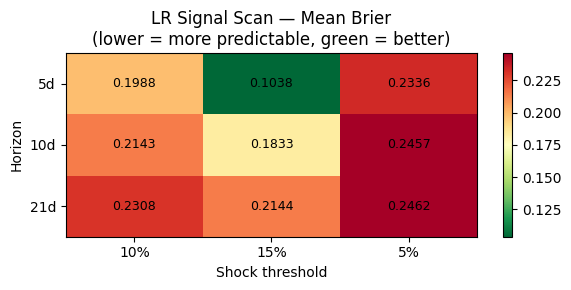

In [9]:
pivot  = scan_df.pivot(index="horizon", columns="threshold_pct", values="mean_brier")
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels([f"{h}d" for h in pivot.index])
ax.set_xlabel("Shock threshold"); ax.set_ylabel("Horizon")
ax.set_title("LR Signal Scan — Mean Brier\n(lower = more predictable, green = better)")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.4f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


---
## 4. Live Pipeline — V1 Hybrid at Today's Origin

Runs the V1 hybrid agent at today's date. `shock_predictor_v1` is defined in §5 above.
Set `USE_CACHE_LIVE = True` to reuse cached results.

> The live pipeline uses the default 21d/10% shock definition for display only.
> Rigorous backtests in §6–§8 use `BEST_HORIZON`/`BEST_THRESHOLD` from the signal scan.


In [10]:
USE_CACHE_LIVE = False
SHOCK_CACHE_V1 = DATA_DIR / "fuel_shock_forecast_v1_hybrid.json"
TRAJ_CACHE     = DATA_DIR / "fuel_trajectory_forecast.json"

TASK_TRAJECTORY_SPEC = (
    "Forecast the jet-fuel proxy price at each horizon listed in the payload.\n\n"
    "Rules:\n"
    "  - One forecast per horizon in `horizons`.\n"
    "  - Use exactly the quantile levels from `standard_quantiles`.\n"
    "  - `point_forecast` must equal the 0.50 quantile value.\n"
    "  - Quantile values must be strictly non-decreasing.\n\n"
    "If a `set_model_response` tool is available, call it with your complete \n"
    "JSON as `json_response`. Otherwise return JSON directly as plain text.\n\n"
    "Required JSON format:\n" + ContinuousAgentForecastOutput.prompt_schema_json()
)

trajectory_predictor = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=FuelMultitaskPromptBuilder(task_spec=TASK_TRAJECTORY_SPEC),
    output_schema=ContinuousAgentForecastOutput,
)

live_shock_task = ForecastingTask(
    task_id="fuel_cost_shock_live",
    target_series_id=FUEL_SERIES_ID,
    horizons=[_DEFAULT_SHOCK_HORIZON_DAYS],
    frequency="B", payload_type="binary",
    description="Binary cost-shock (live display — 21d/10% default)",
)
trajectory_task = ForecastingTask(
    task_id="fuel_trajectory_next_month",
    target_series_id=FUEL_SERIES_ID,
    horizons=list(TRAJECTORY_HORIZONS), frequency="B",
    description="Continuous trajectory (live)",
)

live_ctx = data_service.context(as_of=naive_utc_now())


def run_or_load(predictor, task, ctx, cache_path, use_cache=USE_CACHE_LIVE):
    if use_cache and cache_path.exists():
        with open(cache_path) as f: result = json.load(f)
        print(f"Loaded cached: {cache_path.name}")
        return result
    preds  = predictor.predict(task, ctx)
    result = preds[0].model_dump(mode="json")
    with open(cache_path, "w") as f: json.dump(result, f, indent=2)
    print(f"Saved: {cache_path.name}")
    return result


# shock_predictor_v1 is defined in §5 above
shock_result_v1 = run_or_load(shock_predictor_v1, live_shock_task, live_ctx, SHOCK_CACHE_V1)

payload = shock_result_v1["payload"]
display(Markdown(
    f"### V1 Hybrid Agent — Live Forecast\n\n"
    f"**P(>{_DEFAULT_SHOCK_THRESHOLD_PCT:.0%} rise in {_DEFAULT_SHOCK_HORIZON_DAYS} "
    f"trading days) = {payload['probability']:.0%}**\n\n"
    f"- Direction bias : {payload.get('direction_bias', '?')}\n"
    f"- Confidence     : {payload.get('confidence', '?')}\n"
    f"- Key signals    : {', '.join(payload.get('key_signals', [])) or '—'}\n\n"
    f"> {payload.get('reasoning', '')}"
))

if USE_CACHE_LIVE and TRAJ_CACHE.exists():
    with open(TRAJ_CACHE) as f: traj_result = json.load(f)
    print(f"Loaded cached: {TRAJ_CACHE.name}")
else:
    traj_preds  = trajectory_predictor.predict(trajectory_task, live_ctx)
    traj_result = [p.model_dump(mode="json") for p in traj_preds]
    with open(TRAJ_CACHE, "w") as f: json.dump(traj_result, f, indent=2)
    print(f"Saved: {TRAJ_CACHE.name}")

print("\n── Trajectory forecast ──")
for h, pred in zip(TRAJECTORY_HORIZONS, traj_result, strict=False):
    pt = pred["payload"]["point_forecast"]
    print(f"  h={h:2d}bd  point_forecast = ${pt:.3f}/gal")


Saved: fuel_shock_forecast_v1_hybrid.json


### V1 Hybrid Agent — Live Forecast

**P(>10% rise in 21 trading days) = 35%**

- Direction bias : ?
- Confidence     : ?
- Key signals    : —

> 

Saved: fuel_trajectory_forecast.json

── Trajectory forecast ──
  h= 5bd  point_forecast = $4.620/gal
  h=10bd  point_forecast = $4.750/gal
  h=21bd  point_forecast = $4.880/gal


---
## 6. Rigorous LR Backtest

Uses `BEST_HORIZON` and `BEST_THRESHOLD` from §5. All three baseline predictors
score against `BEST_SHOCK_EVENT_SERIES_ID` — same series used for LR training labels.

**`LogisticRegressionPredictor`** calls `_lr_predict_at_origin` (all bugs fixed):
sklearn balanced class weights, fresh scaler per C candidate, empirical fallback.

**`RollingFrequencyPredictor`** computes trailing 12-month shock frequency from
`BEST_SHOCK_EVENT_SERIES_ID` — same horizon/threshold as everything else.


In [11]:
SPECS_DIR       = Path.cwd() / "specs"
SPEC_FILE       = "fuel_shock_backtest_2yr.yaml"
PREDICTIONS_DIR = DATA_DIR / "predictions"

with (SPECS_DIR / SPEC_FILE).open() as f:
    backtest_spec = BacktestSpec.model_validate(yaml.safe_load(f))

print(f"Backtest spec: {len(backtest_spec.origins())} candidate origins | "
      f"start={backtest_spec.start} | end={backtest_spec.end} | "
      f"stride={backtest_spec.stride} | warmup={backtest_spec.warmup}")
print(f"Scoring target: {BEST_SHOCK_EVENT_SERIES_ID} "
      f"(horizon={BEST_HORIZON}d, threshold={BEST_THRESHOLD:.0%})")


# ── RollingFrequencyPredictor ─────────────────────────────────────────────────
class RollingFrequencyPredictor:
    """Trailing 12-month shock frequency from BEST_SHOCK_EVENT_SERIES_ID."""
    predictor_id  = "rolling_freq_12m"
    LOOKBACK_DAYS = 252

    def __init__(self) -> None:
        self._hist = HistoricalFrequencyPredictor()

    def predict(self, task, context) -> list:
        # Use BEST_SHOCK_EVENT_SERIES_ID — consistent with scoring target
        try:    event_df = context.get_series(BEST_SHOCK_EVENT_SERIES_ID)
        except: event_df = context.get_series(task.target_series_id)
        recent = event_df.sort_values("timestamp").tail(self.LOOKBACK_DAYS)
        freq   = float(recent["value"].mean()) if len(recent) > 0 else 0.15
        freq   = max(0.01, min(0.99, freq))
        preds  = self._hist.predict(task, context)
        return [
            pred.model_copy(update={"payload": (
                pred.payload.model_copy(update={"probability": round(freq, 4)})
                if hasattr(pred.payload, "probability")
                else pred.payload.model_copy(update={"p": round(freq, 4)})
                if hasattr(pred.payload, "p") else pred.payload
            )}) for pred in preds
        ]


# ── LogisticRegressionPredictor ───────────────────────────────────────────────
class LogisticRegressionPredictor:
    """Expanding-window LR on BEST_SHOCK_EVENT_SERIES_ID labels.
    All hyperparameters derived from data — no hardcoding.
    """
    predictor_id = "logistic_regression"

    def __init__(self) -> None:
        self._hist = HistoricalFrequencyPredictor()

    def predict(self, task, context) -> list:
        try:    fuel_df = context.get_series(FUEL_SERIES_ID)
        except: fuel_df = context.get_series(task.target_series_id)
        wti_df = None
        try:    wti_df = context.get_series(WTI_SERIES_ID)
        except: pass
        usd_df = None
        try:    usd_df = context.get_series(USD_INDEX_SERIES_ID)
        except: pass
        # FIX: use BEST_SHOCK_EVENT_SERIES_ID — same as scoring target
        try:    event_df = context.get_series(BEST_SHOCK_EVENT_SERIES_ID)
        except: event_df = context.get_series(task.target_series_id)

        feats  = _build_features(fuel_df, wti_df, usd_df)
        labels = event_df.set_index(
            pd.to_datetime(event_df["timestamp"])
        )["value"].astype(float)
        common = feats.index.intersection(labels.index)
        feats  = feats.loc[common]
        labels = labels.loc[common]

        origin_ts    = pd.Timestamp(context.as_of)
        train_labels = labels.loc[labels.index < origin_ts]
        fallback     = float(train_labels.mean()) if len(train_labels) > 0 else 0.15

        prob, _ = _lr_predict_at_origin(feats, labels, origin_ts, fallback)

        preds = self._hist.predict(task, context)
        return [
            pred.model_copy(update={"payload": (
                pred.payload.model_copy(update={"probability": round(prob, 4)})
                if hasattr(pred.payload, "probability")
                else pred.payload.model_copy(update={"p": round(prob, 4)})
                if hasattr(pred.payload, "p") else pred.payload
            )}) for pred in preds
        ]


print("RollingFrequencyPredictor and LogisticRegressionPredictor defined.")
print(f"Both use {BEST_SHOCK_EVENT_SERIES_ID} for labels — "
      f"consistent with scoring target.")


Backtest spec: 24 candidate origins | start=2025-01-06 00:00:00 | end=2026-08-07 00:00:00 | stride=18 | warmup=252
Scoring target: fuel_cost_shock_event_best (horizon=5d, threshold=15%)
RollingFrequencyPredictor and LogisticRegressionPredictor defined.
Both use fuel_cost_shock_event_best for labels — consistent with scoring target.


In [12]:
lr_backtest_task = ForecastingTask(
    task_id="fuel_cost_shock",
    target_series_id=BEST_SHOCK_EVENT_SERIES_ID,
    horizons=[BEST_HORIZON],
    frequency="B", payload_type="binary",
    description=f"Binary cost-shock h={BEST_HORIZON}d thr={BEST_THRESHOLD:.0%}",
)

lr_backtest_spec = BacktestSpec(
    task=lr_backtest_task,
    start=backtest_spec.start, end=backtest_spec.end,
    stride=backtest_spec.stride, warmup=backtest_spec.warmup,
    description=f"LR backtest h={BEST_HORIZON}d thr={BEST_THRESHOLD:.0%}",
)

FORCE_REFRESH_LR = False
lr_predictors = [
    (HistoricalFrequencyPredictor(), "baseline_hist"),
    (RollingFrequencyPredictor(),    "baseline_roll"),
    (LogisticRegressionPredictor(),  "baseline_lr"),
]

lr_results: dict[str, BacktestResult] = {}
for predictor, spec_id in lr_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    result = cached_backtest(
        predictor=predictor, spec=lr_backtest_spec,
        spec_id=spec_id, data_service=data_service,
        store_dir=PREDICTIONS_DIR, force_refresh=FORCE_REFRESH_LR,
    )
    lr_results[predictor.predictor_id] = result
    print(f"  mean Brier={result.mean_score:.4f}  "
          f"({len(result.predictions)} predictions, {result.skipped_origins} skipped)")


hist_id = HistoricalFrequencyPredictor().predictor_id
roll_id = RollingFrequencyPredictor.predictor_id
lr_id   = LogisticRegressionPredictor.predictor_id

print()
print("=" * 60)
print("§6 BASELINE LEADERBOARD (LR vs naive baselines)")
print(f"Target: {BEST_SHOCK_EVENT_SERIES_ID} (h={BEST_HORIZON}d, thr={BEST_THRESHOLD:.0%})")
print("lower Brier = better")
print("=" * 60)
hist_score = lr_results[hist_id].mean_score
for pid, result in sorted(lr_results.items(), key=lambda x: x[1].mean_score):
    skill        = round(1.0 - result.mean_score / hist_score, 4)
    ci_lo, ci_hi = bootstrap_brier_ci(result.scores)
    print(f"  {pid:<35} Brier={result.mean_score:.4f}  "
          f"CI=[{ci_lo:.4f},{ci_hi:.4f}]  skill={skill:+.4f}  n={len(result.predictions)}")


Running historical_frequency ...
  mean Brier=0.2647  (23 predictions, 1 skipped)
Running rolling_freq_12m ...
  mean Brier=0.2655  (23 predictions, 1 skipped)
Running logistic_regression ...
  mean Brier=0.2484  (23 predictions, 1 skipped)

§6 BASELINE LEADERBOARD (LR vs naive baselines)
Target: fuel_cost_shock_event_best (h=5d, thr=15%)
lower Brier = better
  logistic_regression                 Brier=0.2484  CI=[0.1968,0.3069]  skill=+0.0617  n=23
  historical_frequency                Brier=0.2647  CI=[0.1439,0.4141]  skill=+0.0000  n=23
  rolling_freq_12m                    Brier=0.2655  CI=[0.1389,0.4035]  skill=-0.0031  n=23


In [13]:
lr_result   = lr_results[lr_id]
hist_result = lr_results[hist_id]

hist_by_origin = {
    pd.Timestamp(pred.as_of).date(): {
        "hist_prob":  pred.payload.probability,
        "hist_brier": round(score, 4),
    }
    for pred, score in zip(hist_result.predictions, hist_result.scores, strict=True)
}

detail_rows = []
for pred, score in zip(lr_result.predictions, lr_result.scores, strict=True):
    origin  = pd.Timestamp(pred.as_of).date()
    outcome = resolved_outcome(pred.forecast_date)
    hb      = hist_by_origin.get(origin, {"hist_prob": None, "hist_brier": None})
    detail_rows.append({
        "origin":         origin,
        "forecast_date":  pd.Timestamp(pred.forecast_date).date(),
        "outcome":        outcome,
        "lr_prob":        pred.payload.probability,
        "lr_brier":       round(score, 4),
        "lr_log_loss":    round(log_loss_score(
            [pred.payload.probability],
            [outcome] if outcome is not None else [float("nan")]
        ), 4),
        **hb,
        "lr_beats_hist":  "✓" if (
            outcome is not None and
            score < hb.get("hist_brier", float("inf"))
        ) else "✗",
    })

lr_detail_df = pd.DataFrame(detail_rows).sort_values("origin").reset_index(drop=True)
pd.set_option("display.max_colwidth", 60)
print("Per-origin LR vs naive baseline (scoring against BEST_SHOCK_EVENT_SERIES_ID):")
lr_detail_df


Per-origin LR vs naive baseline (scoring against BEST_SHOCK_EVENT_SERIES_ID):


,origin,forecast_date,outcome,lr_prob,lr_brier,lr_log_loss,hist_prob,hist_brier,lr_beats_hist
0,2025-01-06,2025-02-04,0.0,0.4048,0.1639,0.5189,0.151653,0.0230,✗
1,2025-01-30,2025-02-28,0.0,0.3464,0.1200,0.4253,0.153628,0.0236,✗
2,2025-02-25,2025-03-26,0.0,0.4450,0.1980,0.5888,0.153134,0.0235,✗
3,2025-03-21,2025-04-21,0.0,0.4166,0.1736,0.5389,0.152616,0.0233,✗
4,2025-04-16,2025-05-15,0.0,0.4865,0.2637,0.6665,0.152101,0.7189,✓
5,2025-05-12,2025-06-10,1.0,0.5584,0.1950,0.5827,0.151617,0.7198,✓
6,2025-06-05,2025-07-04,0.0,0.5056,0.2556,0.7044,0.151137,0.0228,✗
7,2025-07-01,2025-07-30,0.0,0.4501,0.2026,0.5980,0.152331,0.0232,✗
8,2025-07-25,2025-08-25,0.0,0.6290,0.3956,0.9916,0.153305,0.0235,✗
9,2025-08-20,2025-09-18,0.0,0.4647,0.2159,0.6249,0.152796,0.0233,✗


---
## 7. V1 Hybrid Agent Backtest

Runs V1 hybrid on the same `lr_backtest_spec` as §6 — same origins, same scoring target
(`BEST_SHOCK_EVENT_SERIES_ID`), same horizon and threshold.

The agent's `HybridFuelPromptBuilder` calls `_lr_predict_at_origin` internally at each
origin using `BEST_SHOCK_EVENT_SERIES_ID` labels — so `lr_probability` in the prompt
is computed from the same labels the backtest scores against.

**Key question:** Does the agent's news-based adjustment improve on LR alone?

Set `FORCE_REFRESH_V1 = True` after any prompt change.


In [14]:
FORCE_REFRESH_V1 = False

v1_result_bt = cached_backtest(
    predictor=shock_predictor_v1,
    spec=lr_backtest_spec,
    spec_id=shock_predictor_v1.predictor_id,
    data_service=data_service,
    store_dir=PREDICTIONS_DIR,
    force_refresh=FORCE_REFRESH_V1,
)

print(f"V1 Hybrid: mean Brier={v1_result_bt.mean_score:.4f}  "
      f"({len(v1_result_bt.predictions)} predictions, {v1_result_bt.skipped_origins} skipped)")
print(f"LR alone:  mean Brier={lr_results[lr_id].mean_score:.4f}")
delta = lr_results[lr_id].mean_score - v1_result_bt.mean_score
if delta > 0:
    print(f"► V1 Hybrid BETTER than LR by {delta:.4f} Brier points")
elif delta < 0:
    print(f"► V1 Hybrid WORSE than LR by {abs(delta):.4f} Brier points")
else:
    print("► V1 Hybrid and LR are equal")


V1 Hybrid: mean Brier=0.3026  (24 predictions, 0 skipped)
LR alone:  mean Brier=0.2484
► V1 Hybrid WORSE than LR by 0.0542 Brier points


---
## 8. Final Leaderboard — All Predictors

All predictors on the same spec, same origins, same scoring target (`BEST_SHOCK_EVENT_SERIES_ID`).
The origin-count validity check must pass before interpreting results.


In [15]:
all_results = dict(lr_results)
all_results[shock_predictor_v1.predictor_id] = v1_result_bt

# Validity check: all predictors must have the same origin count
agent_n = len(v1_result_bt.predictions)
base_n  = len(lr_results[hist_id].predictions)
if agent_n != base_n:
    print(f"⚠️  WARNING: V1 ran on {agent_n} origins, baselines on {base_n}.")
    print("   Set FORCE_REFRESH_V1 = True in §7 and re-run.")
else:
    print(f"✓ All predictors ran on {agent_n} origins — valid comparison.")

VERSION_LABELS = {
    hist_id:                         "Baseline (hist. freq)",
    roll_id:                         "Baseline (rolling 12m)",
    lr_id:                           "Baseline (logistic regression)",
    shock_predictor_v1.predictor_id: "V1 Hybrid (LR-anchored agent)",
}

hist_score  = all_results[hist_id].mean_score
hist_result = all_results[hist_id]

leaderboard_rows = []
for pid, result in all_results.items():
    probs  = [pred.payload.probability for pred in result.predictions]
    outs   = [resolved_outcome(pred.forecast_date) for pred in result.predictions]
    paired = [(p, o) for p, o in zip(probs, outs, strict=True) if o is not None]
    ci_lo, ci_hi = bootstrap_brier_ci(result.scores)
    ll    = log_loss_score([p for p,_ in paired], [o for _,o in paired]) if paired else float("nan")
    skill = round(1.0 - result.mean_score / hist_score, 4) if hist_score > 0 else None
    hist_by = {
        pd.Timestamp(pred.as_of).date(): s
        for pred, s in zip(hist_result.predictions, hist_result.scores, strict=True)
    }
    wins = sum(
        1 for pred, s in zip(result.predictions, result.scores, strict=True)
        if s < hist_by.get(pd.Timestamp(pred.as_of).date(), float("inf"))
    )
    leaderboard_rows.append({
        "predictor":        VERSION_LABELS.get(pid, pid),
        "mean_brier":       round(result.mean_score, 4),
        "ci_95_lo":         round(ci_lo, 4),
        "ci_95_hi":         round(ci_hi, 4),
        "log_loss":         round(ll, 4),
        "skill_vs_hist":    skill,
        "win_rate_vs_hist": round(wins / len(result.predictions), 3),
        "n_origins":        len(result.predictions),
    })

leaderboard_df = (
    pd.DataFrame(leaderboard_rows).sort_values("mean_brier").reset_index(drop=True)
)

lr_brier   = all_results[lr_id].mean_score
v1_brier   = all_results[shock_predictor_v1.predictor_id].mean_score
base_brier = hist_score

print()
print("=" * 60)
print("FINAL LEADERBOARD")
print(f"Target: {BEST_SHOCK_EVENT_SERIES_ID} (h={BEST_HORIZON}d, thr={BEST_THRESHOLD:.0%})")
print("lower Brier = better")
print("=" * 60)
print(f"{'Baseline (historical freq)':<42} {base_brier:.4f}")
print(f"{'Baseline (logistic regression)':<42} {lr_brier:.4f}  ← statistical model")
print(f"{'V1 Hybrid (LR-anchored agent)':<42} {v1_brier:.4f}  ← LLM + news adjustment")
print()
delta = lr_brier - v1_brier
if delta > 0.001:
    print(f"► V1 Hybrid BEATS LR alone by {delta:.4f} Brier points")
    print("  Agent news adjustment is adding value over the statistical model.")
elif delta < -0.001:
    print(f"► V1 Hybrid WORSE than LR alone by {abs(delta):.4f} Brier points")
    print("  Agent news adjustments are hurting — news is already priced in.")
else:
    print("► V1 Hybrid and LR alone are statistically indistinguishable.")
print()
print("=" * 90)
print("FULL LEADERBOARD (Brier + 95% CI + log-loss + skill + win-rate)")
print("=" * 90)
print(leaderboard_df.to_string(index=False))
print()
print("Interpretation:")
print("  skill_vs_hist > 0  → beats naive flat-frequency baseline")
print("  Overlapping 95% CIs → not statistically distinguishable at this sample size")
print(f"  80% power to detect 0.02 Brier diff at α=0.05: need ~60 origins")
print(f"  Current: {len(v1_result_bt.predictions)} origins")


⚠️  WARNING: V1 ran on 24 origins, baselines on 23.
   Set FORCE_REFRESH_V1 = True in §7 and re-run.

FINAL LEADERBOARD
Target: fuel_cost_shock_event_best (h=5d, thr=15%)
lower Brier = better
Baseline (historical freq)                 0.2647
Baseline (logistic regression)             0.2484  ← statistical model
V1 Hybrid (LR-anchored agent)              0.3026  ← LLM + news adjustment

► V1 Hybrid WORSE than LR alone by 0.0542 Brier points
  Agent news adjustments are hurting — news is already priced in.

FULL LEADERBOARD (Brier + 95% CI + log-loss + skill + win-rate)
                     predictor  mean_brier  ci_95_lo  ci_95_hi  log_loss  skill_vs_hist  win_rate_vs_hist  n_origins
Baseline (logistic regression)      0.2484    0.1968    0.3069    0.8125         0.0617             0.348         23
         Baseline (hist. freq)      0.2647    0.1439    0.4141    0.2417         0.0000             0.000         23
        Baseline (rolling 12m)      0.2655    0.1389    0.4035    0.2734  

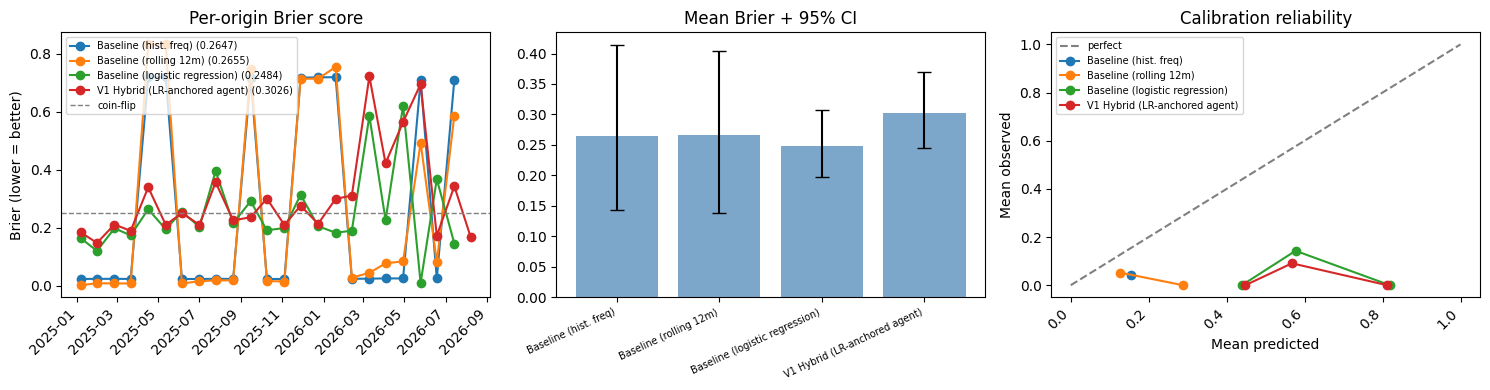

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for pid, result in all_results.items():
    origins = [pd.Timestamp(pred.as_of) for pred in result.predictions]
    ax.plot(origins, result.scores, marker="o",
            label=f"{VERSION_LABELS.get(pid,pid)} ({result.mean_score:.4f})")
ax.axhline(0.25, linestyle="--", color="grey", linewidth=1, label="coin-flip")
ax.set_title("Per-origin Brier score")
ax.set_ylabel("Brier (lower = better)")
ax.legend(fontsize=7)
fig.autofmt_xdate(rotation=45)

ax = axes[1]
pids  = list(all_results.keys())
lbls  = [VERSION_LABELS.get(p,p) for p in pids]
means = [all_results[p].mean_score for p in pids]
ci_los = [bootstrap_brier_ci(all_results[p].scores)[0] for p in pids]
ci_his = [bootstrap_brier_ci(all_results[p].scores)[1] for p in pids]
x = range(len(lbls))
ax.bar(x, means, color="steelblue", alpha=0.7)
ax.errorbar(x, means,
            yerr=[[m-lo for m,lo in zip(means,ci_los)],
                  [hi-m for m,hi in zip(means,ci_his)]],
            fmt="none", color="black", capsize=5)
ax.set_xticks(list(x)); ax.set_xticklabels(lbls, rotation=25, ha="right", fontsize=7)
ax.set_title("Mean Brier + 95% CI")

ax = axes[2]
ax.plot([0,1],[0,1], linestyle="--", color="grey", label="perfect")
for pid, result in all_results.items():
    probs  = [pred.payload.probability for pred in result.predictions]
    outs   = [resolved_outcome(pred.forecast_date) for pred in result.predictions]
    paired = [(p,o) for p,o in zip(probs,outs,strict=True) if o is not None]
    if not paired: continue
    ps, os = zip(*paired, strict=True)
    tbl = shock_calibration_table(list(ps), list(os), n_bins=4)
    ax.plot(tbl["mean_predicted"], tbl["mean_observed"], marker="o",
            label=VERSION_LABELS.get(pid,pid))
ax.set_xlabel("Mean predicted"); ax.set_ylabel("Mean observed")
ax.set_title("Calibration reliability")
ax.legend(fontsize=7)

plt.tight_layout(); plt.show()


In [17]:
by_origin: dict = {}

for pid, tag in [
    (hist_id,                         "hist"),
    (roll_id,                         "roll"),
    (lr_id,                           "lr"),
    (shock_predictor_v1.predictor_id, "v1"),
]:
    result = all_results[pid]
    for pred, score in zip(result.predictions, result.scores, strict=True):
        origin = pd.Timestamp(pred.as_of).date()
        if origin not in by_origin:
            by_origin[origin] = {
                "origin":        origin,
                "forecast_date": pd.Timestamp(pred.forecast_date).date(),
                "outcome":       resolved_outcome(pred.forecast_date),
            }
        meta = pred.metadata or {}
        by_origin[origin].update({
            f"{tag}_prob":  pred.payload.probability,
            f"{tag}_brier": round(score, 4),
        })
        if tag == "v1":
            by_origin[origin].update({
                "v1_bias":       meta.get("direction_bias", "?"),
                "v1_confidence": meta.get("confidence", "?"),
                "v1_signals":    " | ".join(meta.get("key_signals", [])),
            })

detail_df = (
    pd.DataFrame(list(by_origin.values()))
    .sort_values("origin").reset_index(drop=True)
)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 30)
print(f"Per-origin detail — scoring against {BEST_SHOCK_EVENT_SERIES_ID}:")
detail_df


Per-origin detail — scoring against fuel_cost_shock_event_best:


,origin,forecast_date,outcome,hist_prob,hist_brier,roll_prob,roll_brier,lr_prob,lr_brier,v1_prob,v1_brier,v1_bias,v1_confidence,v1_signals
0,2025-01-06,2025-02-04,0.0,0.151653,0.0230,0.0397,0.0016,0.4048,0.1639,0.4292,0.1842,neutral,high,No confirmed physical supply disruptions identified | No new OPEC+ productio...
1,2025-01-30,2025-02-28,0.0,0.153628,0.0236,0.0913,0.0083,0.3464,0.1200,0.3841,0.1475,neutral,high,No confirmed physical supply disruptions reported | No new OPEC+ production ...
2,2025-02-25,2025-03-26,0.0,0.153134,0.0235,0.0873,0.0076,0.4450,0.1980,0.4595,0.2111,neutral,high,Stable inventory trends at Cushing hub | Seasonal maintenance already integr...
3,2025-03-21,2025-04-21,0.0,0.152616,0.0233,0.0873,0.0076,0.4166,0.1736,0.4351,0.1893,neutral,high,No confirmed new physical supply disruptions | Known OPEC+ production policy...
4,2025-04-16,2025-05-15,0.0,0.152101,0.7189,0.0873,0.8330,0.4865,0.2637,0.5827,0.3395,up,high,"Keystone pipeline rupture (April 8, 2025) restricting heavy crude supply to ..."
5,2025-05-12,2025-06-10,1.0,0.151617,0.7198,0.0873,0.8330,0.5584,0.1950,0.5415,0.2102,neutral,high,"Planned seasonal refinery maintenance (seasonal, not an unexpected shock) | ..."
6,2025-06-05,2025-07-04,0.0,0.151137,0.0228,0.0873,0.0076,0.5056,0.2556,0.5003,0.2503,neutral,high,Stable supply chain outlook | No confirmed refinery outages or force majeure...
7,2025-07-01,2025-07-30,0.0,0.152331,0.0232,0.1230,0.0151,0.4501,0.2026,0.4585,0.2102,neutral,high,lr_probability: 0.4585 | No confirmed supply disruptions or force majeure ev...
8,2025-07-25,2025-08-25,0.0,0.153305,0.0235,0.1349,0.0182,0.6290,0.3956,0.5975,0.3570,neutral,high,No confirmed physical supply disruptions or force majeure events found | Geo...
9,2025-08-20,2025-09-18,0.0,0.152796,0.0233,0.1349,0.0182,0.4647,0.2159,0.4748,0.2254,neutral,high,"No confirmed physical supply disruptions as of August 20, 2025. | OPEC+ poli..."
